# Atelier Seaborn 

## Structure du projet 
### 4. Installer et importer seaborn, matplotlib, pandas, numpy

In [137]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib as plt

print("Seaborn version :", sns.__version__)
print("Pandas version  :", pd.__version__)
print("NumPy version   :", np.__version__)


Seaborn version : 0.13.2
Pandas version  : 3.0.5
NumPy version   : 2.5.2


### 5. Importer mesures_capteurs.csv dans le dataframe df 

In [138]:
import pandas as pd

df = pd.read_csv("../data/mesures_capteurs.csv")


### 6. Vérifier le contenu du dataframe df 

In [139]:
# Vérification rapide du volume des données
print(f"Le tableau de données contient {df.shape[0]} lignes et {df.shape[1]} colonnes.\n")
# Afficher les 5 premières lignes pour inspecter le contenu
df.head()

Le tableau de données contient 605 lignes et 9 colonnes.



,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


## Partie 1 – Distribution d'une variable avec histplot() 
### 1) Afficher la distribution des températures 

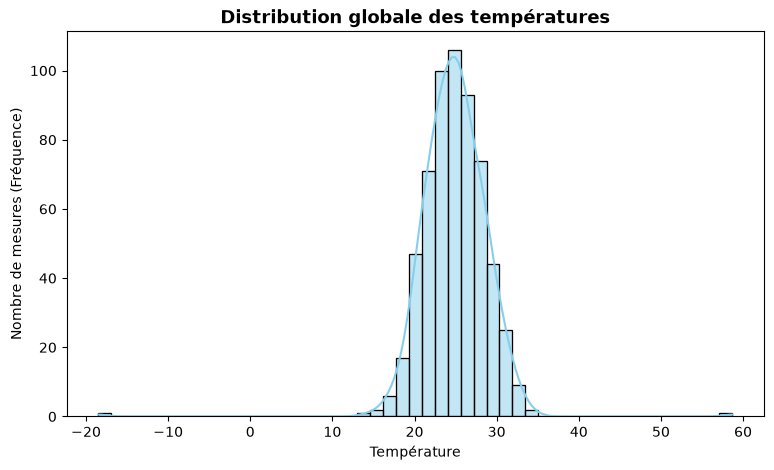

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5)) # Définit la taille du graphique en pouces (largeur=9, hauteur=5)
# On trace l'histogramme avec une estimation lissée de la densité (kde=True)
sns.histplot(data=df, x=df['temperature'], kde=True, color='skyblue')
# Personnalisation des titres et axes
plt.title("Distribution globale des températures", fontsize=13, fontweight='bold')
plt.xlabel("Température")
plt.ylabel("Nombre de mesures (Fréquence)")
plt.show()

### 2) Autour de quelle valeur les températures sont-elles concentrées ?

In [141]:
print(f"la moyenne est de : {df['temperature'].mean()}")
print(f"la mediane est de : {df['temperature'].median()}")


la moyenne est de : 24.87831385642738
la mediane est de : 24.86



En observant le sommet du pic de l'histogramme ci-dessus, on constate que la plus forte concentration des températures se situe autour de **25°C** (la moyenne calculée est de **24,88°C** et la valeur médiane est à **24,86°C**).

### 3) La distribution semble-t-elle symétrique ?

**Oui, elle semble symétrique**. La courbe (KDE) dessine une jolie forme en cloche , ce qui signifie que les températures s'écartent de manière équilibrée de part et d'autre de la moyenne centrale de 25°C.

### 4) Existe-t-il des valeurs extrêmes ?

**Oui, il y a de grosses valeurs extrêmes**. On constate une plage de valeurs normales entre 14°C et 35°C, mais on remarque de très rares points extrêmes isolés aux deux bords : des mesures négatives allant jusqu'à **-18°C** et une température très élevée atteignant **58°C**.

### 5) Modifier le nombre de classes (bins)

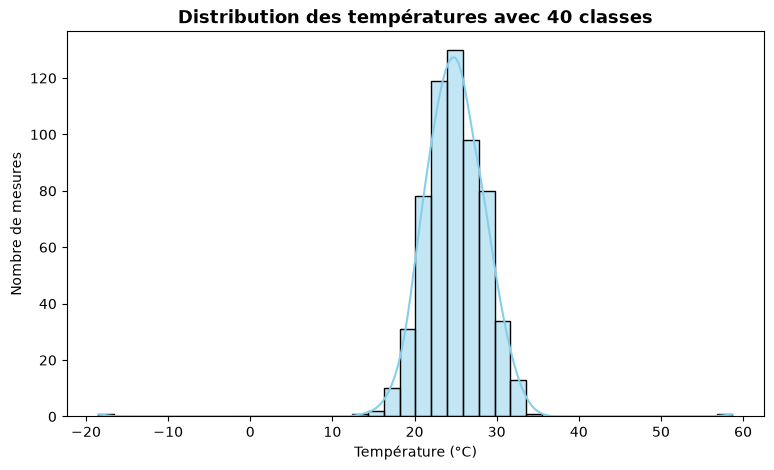

In [142]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x=df['temperature'], bins=40, kde=True, color='skyblue')
plt.title("Distribution des températures avec 40 classes", fontsize=13, fontweight='bold')
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
plt.show()

### 6) Afficher la distribution des températures par bâtiment

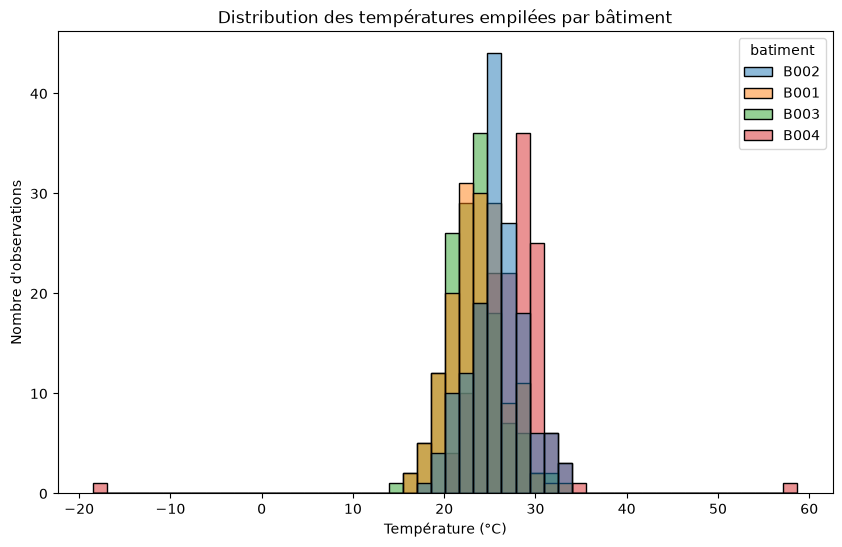

In [143]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=df['temperature'], hue='batiment' ,bins=50)
plt.title("Distribution des températures empilées par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre d'observations")
plt.show()

## Partie 2 – Distribution d'une variable avec kdeplot() 
### 1) Afficher la distribution des températures 

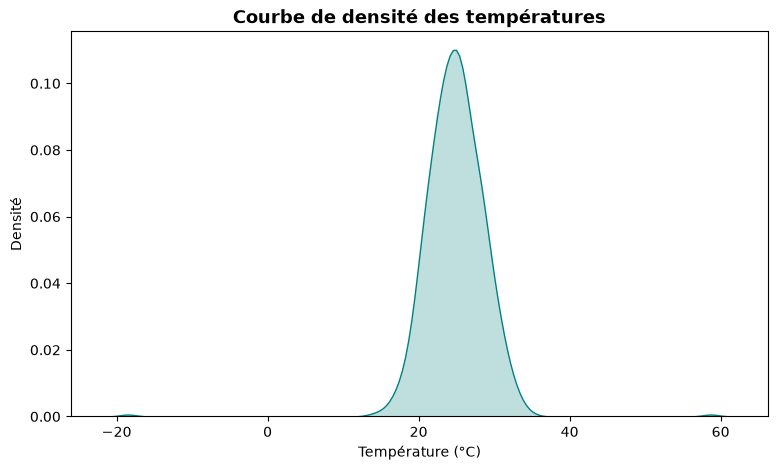

In [144]:
plt.figure(figsize=(9, 5))

# 'fill=True' permet d'ombrer l'aire sous la courbe pour un aspect professionnel
sns.kdeplot(data=df, x=df['temperature'], fill=True, color='teal')
plt.title("Courbe de densité des températures", fontsize=13, fontweight='bold')
plt.xlabel("Température (°C)")
plt.ylabel("Densité")
plt.show()

2) Afficher la distribution des températures par bâtiment 

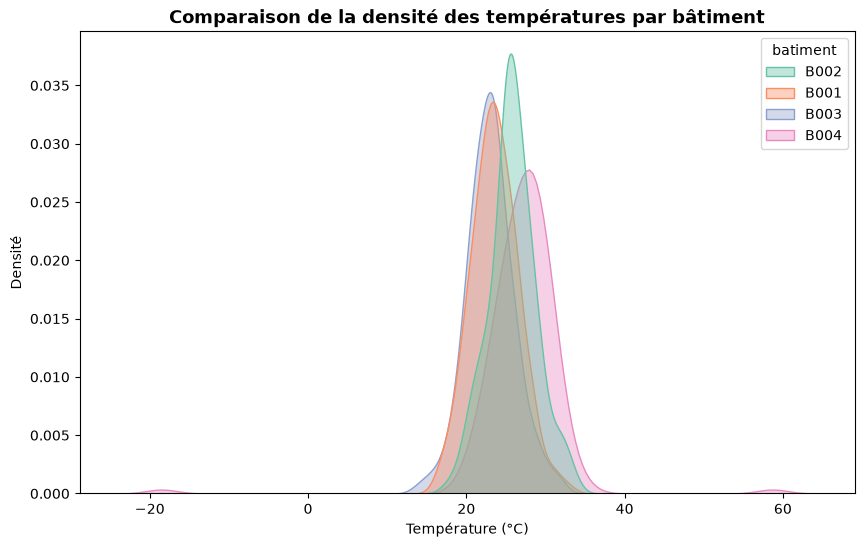

In [145]:
plt.figure(figsize=(10, 6))

# 'hue' crée une courbe de couleur par bâtiment
# 'alpha=0.4' ajoute de la transparence pour voir la superposition des différentes courbes
sns.kdeplot(data=df, x=df['temperature'], hue='batiment', fill=True, palette='Set2', alpha=0.4)
plt.title("Comparaison de la densité des températures par bâtiment", fontsize=13, fontweight='bold')
plt.xlabel("Température (°C)")
plt.ylabel("Densité")
plt.show()

## Partie 3 – Distribution d'une variable avec boxplot() 
### 1) Afficher la distribution des températures 

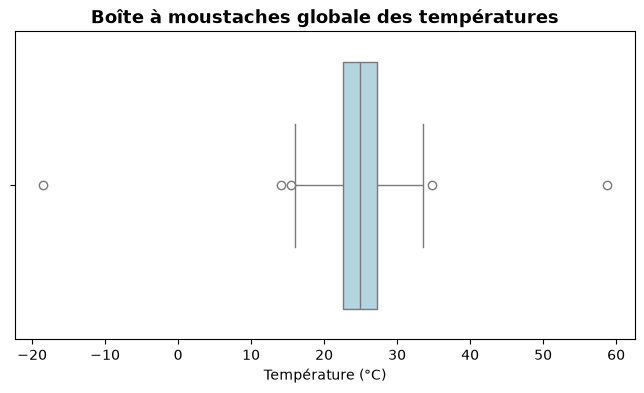

In [146]:
plt.figure(figsize=(8, 4))
# Un box plot horizontal montre d'un coup d'oeil la médiane, les quartiles et les valeurs atypiques
sns.boxplot(data=df, x=df['temperature'], color='lightblue')
plt.title("Boîte à moustaches globale des températures", fontsize=13, fontweight='bold')
plt.xlabel("Température (°C)")
plt.show()

### 2) Afficher la distribution des températures par bâtiment 

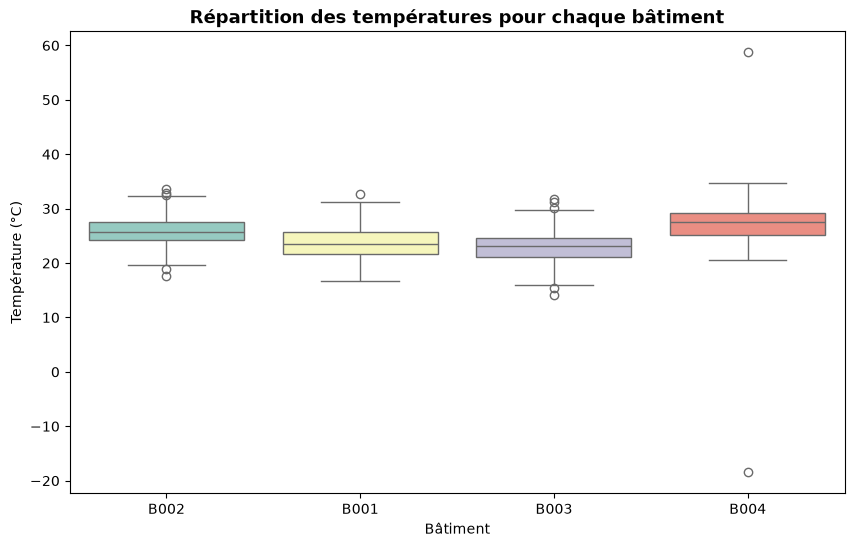

In [147]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="batiment",
    y="temperature",
    hue="batiment",
    palette="Set3",
    legend=False
)

plt.title("Répartition des températures pour chaque bâtiment",
          fontsize=13, fontweight="bold")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")
plt.show()

### 3) Calcul et analyse statistique pour chaque bâtiment :
**a) Quelle est la médiane ?**
**b) Quelle est la dispersion ?**
**c) Les valeurs extrêmes**

In [148]:
# Code pour extraire et imprimer les valeurs exactes calculées par Pandas
for bat in sorted(df['batiment'].unique()):
    temp_bat = df[df['batiment'] == bat]['temperature'].dropna()
    q1 = temp_bat.quantile(0.25)
    q3 = temp_bat.quantile(0.75)
    med = temp_bat.median()
    iqr = q3 - q1 # Dispersion représentée par la taille de la boîte (Écart interquartile)
    
    print(f"Bâtiment {bat} :")
    print(f"  -> Médiane : {med:.2f}°C")
    print(f"  -> Dispersion (boîte / IQR) : {iqr:.2f}°C (allant de {q1:.2f}°C à {q3:.2f}°C)")
    print(f"  -> Valeurs réelles relevées : de {temp_bat.min():.2f}°C à {temp_bat.max():.2f}°C\n")

Bâtiment B001 :
  -> Médiane : 23.54°C
  -> Dispersion (boîte / IQR) : 4.06°C (allant de 21.61°C à 25.67°C)
  -> Valeurs réelles relevées : de 16.77°C à 32.72°C

Bâtiment B002 :
  -> Médiane : 25.67°C
  -> Dispersion (boîte / IQR) : 3.26°C (allant de 24.27°C à 27.53°C)
  -> Valeurs réelles relevées : de 17.67°C à 33.60°C

Bâtiment B003 :
  -> Médiane : 23.05°C
  -> Dispersion (boîte / IQR) : 3.51°C (allant de 21.08°C à 24.59°C)
  -> Valeurs réelles relevées : de 14.11°C à 31.74°C

Bâtiment B004 :
  -> Médiane : 27.53°C
  -> Dispersion (boîte / IQR) : 4.11°C (allant de 25.17°C à 29.28°C)
  -> Valeurs réelles relevées : de -18.50°C à 58.70°C



### 4) Quels bâtiments ont les valeurs les plus extrêmes ?

C'est le **bâtiment B004** qui regroupe les valeurs les plus aberrantes de l'ensemble de l'étude (un minimum insensé de **-18,50°C** et un pic anormal de **58,70°C**), ce qui démontre sans doute un dysfonctionnement de capteurs dans cette zone.

## Partie 4 – Distribution d'une variable avec violinplot() 
### 1) Afficher la distribution des températures 

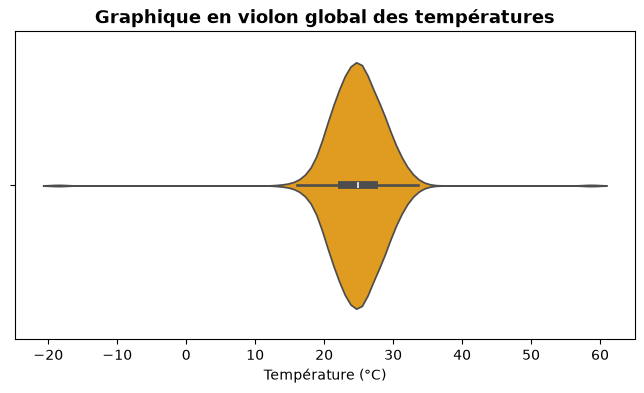

In [149]:
plt.figure(figsize=(8, 4))

# Le violin plot dessine une silhouette symétrique représentant la densité
sns.violinplot(data=df, x='temperature', color='orange')
plt.title("Graphique en violon global des températures", fontsize=13, fontweight='bold')
plt.xlabel("Température (°C)")
plt.show()

### 2) Afficher la distribution des températures par bâtiment 

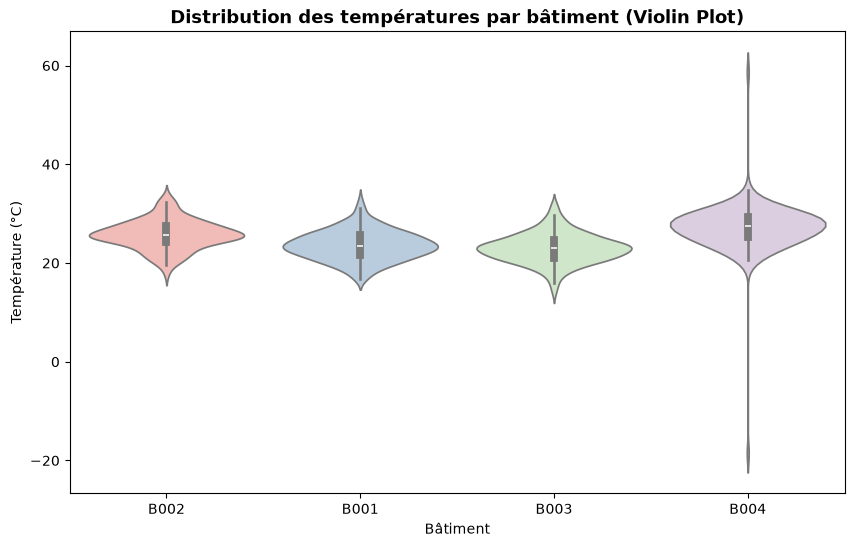

In [150]:
plt.figure(figsize=(10, 6))
# Affichage simultané des violons par bâtiment
sns.violinplot(
    data=df,
    x="batiment",
    y="temperature",
    hue="batiment",
    palette="Pastel1",
    legend=False
)

plt.title("Distribution des températures par bâtiment (Violin Plot)",
          fontsize=13, fontweight="bold")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")
plt.show()

### 3) Quelles informations supplémentaires le violin plot permet-il de visualiser par rapport au box plot ?

Le graphique en violon combine la richesse statistique du box plot et d'une courbe de densité (KDE). Il nous donne la **forme complète et détaillée de la distribution**. 
Si un ensemble contient plusieurs regroupements de valeurs, le Box Plot dessinera simplement un grand rectangle sans rien montrer d'autre. Le Violin Plot, lui, va s'élargir visiblement à chaque niveau de concentration de données, nous révélant ainsi ces sous-groupes de données.

## Partie 5 – Comptage des catégories avec countplot() 
### 1) Afficher le nombre de mesures par état  

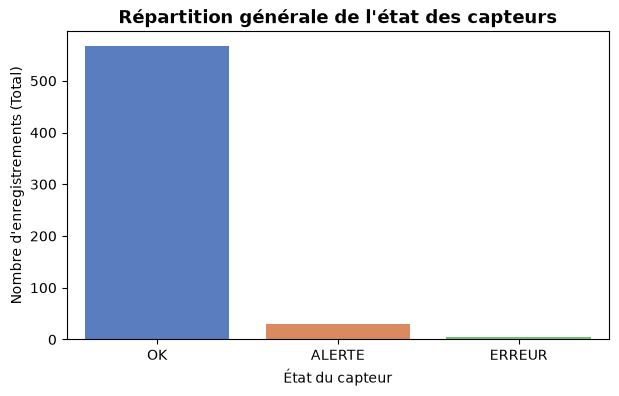

In [151]:
plt.figure(figsize=(7, 4))

# countplot compte automatiquement le nombre d'apparitions de chaque catégorie
sns.countplot(
    data=df,
    x="etat",
    hue="etat",
    palette="muted",
    legend=False
)
plt.title("Répartition générale de l'état des capteurs", fontsize=13, fontweight='bold')
plt.xlabel("État du capteur")
plt.ylabel("Nombre d'enregistrements (Total)")
plt.show()

### 2) Afficher le nombre de mesures par bâtiment 

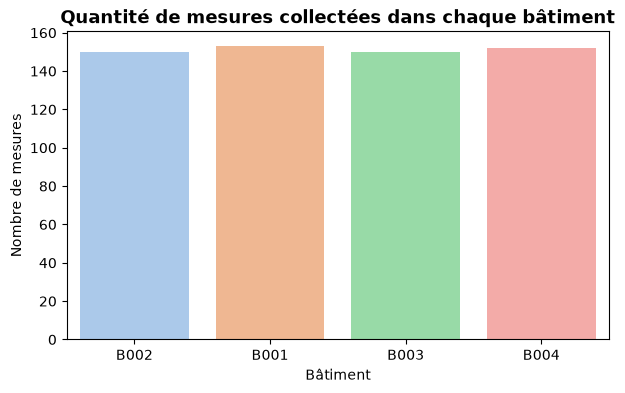

In [152]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='batiment',hue='batiment', palette='pastel')
plt.title("Quantité de mesures collectées dans chaque bâtiment", fontsize=13, fontweight='bold')
plt.xlabel("Bâtiment")
plt.ylabel("Nombre de mesures")
plt.show()

### 3) Afficher les états des capteurs par bâtiment pour identifier :

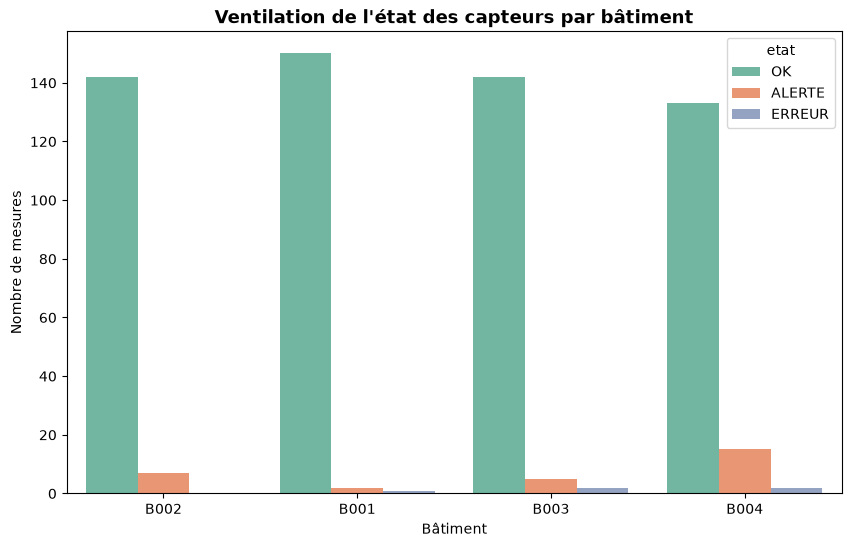

Tableau des effectifs croisés :


etat,ALERTE,ERREUR,OK,All
batiment,,,,
B001,2,1,150,153
B002,7,0,142,149
B003,5,2,142,149
B004,15,2,133,150
All,29,5,567,601


In [153]:
plt.figure(figsize=(10, 6))

# Nous croisons les deux catégories grâce à 'hue' qui sépare les couleurs selon l'état des capteurs
sns.countplot(data=df, x='batiment', hue='etat', palette='Set2')

plt.title("Ventilation de l'état des capteurs par bâtiment", fontsize=13, fontweight='bold')
plt.xlabel("Bâtiment")
plt.ylabel("Nombre de mesures")
plt.show()

# Affichons le tableau exact calculé par Pandas pour confirmer l'interprétation graphique
tableau_croise = pd.crosstab(df['batiment'], df['etat'], margins=True)
print("Tableau des effectifs croisés :")
tableau_croise

**a) Bâtiment ayant le plus de mesures en état OK :** C'est le **bâtiment B001** avec exactement **150 mesures en état OK** (très bonne stabilité matérielle).

**b) Bâtiment ayant le plus de mesures en ALERTE :** C'est le **bâtiment B004** avec **15 mesures en état d'ALERTE** (les autres bâtiments n'ont que 2 à 7 alertes).

**c) Bâtiment ayant le plus de mesures en ERREUR :** Les bâtiments **B003** et **B004** sont à égalité avec **2 mesures en état d'ERREUR** chacun (B001 en a 1, et B002 n'en a aucune).

## Partie 6 – Relation entre deux variables avec scatterplot() 
### 1) Etudier graphiquement la relation entre température et consommation 

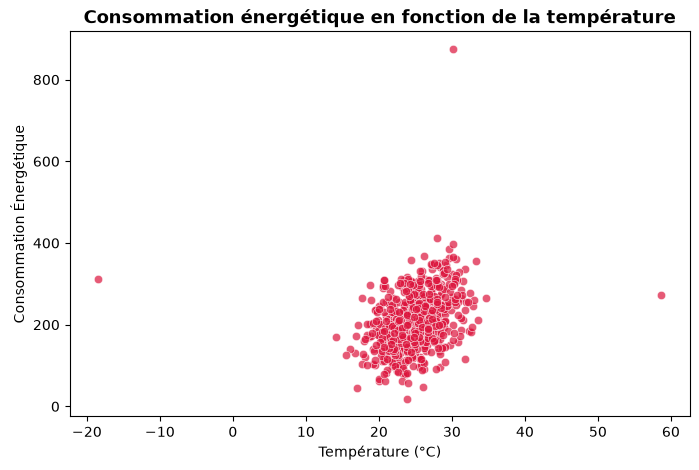

In [154]:
plt.figure(figsize=(8, 5))

# Nuage de points classique entre deux variables réelles
sns.scatterplot(data=df, x='temperature', y='consommation', color='crimson', alpha=0.7)

plt.title("Consommation énergétique en fonction de la température", fontsize=13, fontweight='bold')
plt.xlabel("Température (°C)")
plt.ylabel("Consommation Énergétique")
plt.show()

### 2) Etudier graphiquement la relation entre température et consommation par bâtiment 

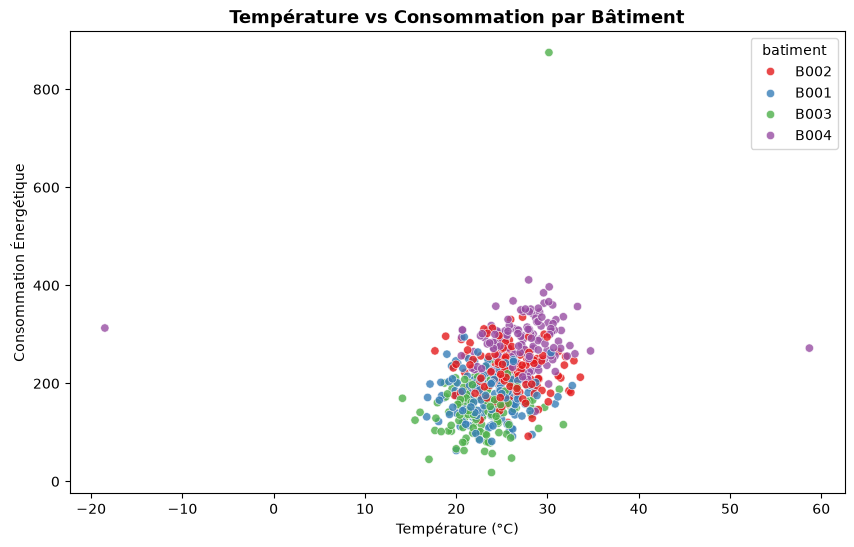

In [155]:
plt.figure(figsize=(10, 6))

# On colorie les points par bâtiment pour distinguer le comportement énergétique de chacun d'eux
sns.scatterplot(data=df, x='temperature', y='consommation', hue='batiment', palette='Set1', alpha=0.8)

plt.title("Température vs Consommation par Bâtiment", fontsize=13, fontweight='bold')
plt.xlabel("Température (°C)")
plt.ylabel("Consommation Énergétique")
plt.show()

### 3) Modifier la taille des points 

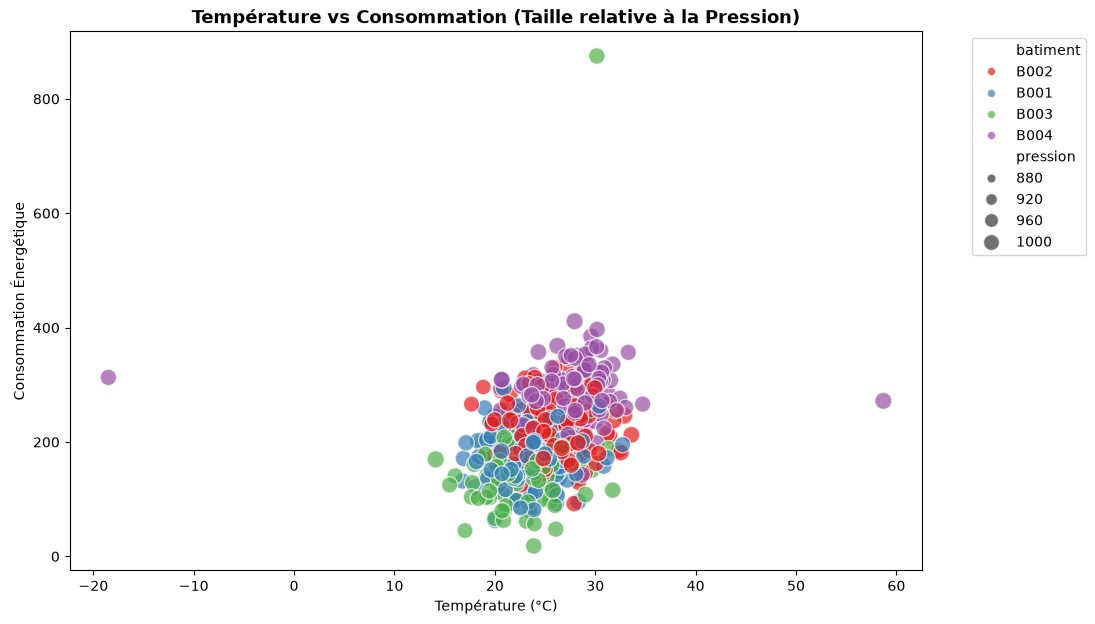

In [156]:
plt.figure(figsize=(11, 7))

# Nous pouvons corréler la dimension des points ('size') à une autre variable (par ex: la pression atmosphérique)
# 'sizes=(20, 150)' contrôle le diamètre minimum et maximum de nos points à l'écran
sns.scatterplot(data=df, x='temperature', y='consommation', hue='batiment', size='pression', sizes=(20, 160), palette='Set1', alpha=0.7)

plt.title("Température vs Consommation (Taille relative à la Pression)", fontsize=13, fontweight='bold')
plt.xlabel("Température (°C)")
plt.ylabel("Consommation Énergétique")

# Positionnement pratique de la légende à l'extérieur droit pour ne pas gêner la lecture
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Partie 7 – Régression avec regplot() 
Etudier graphiquement une tendance entre température et consommation 

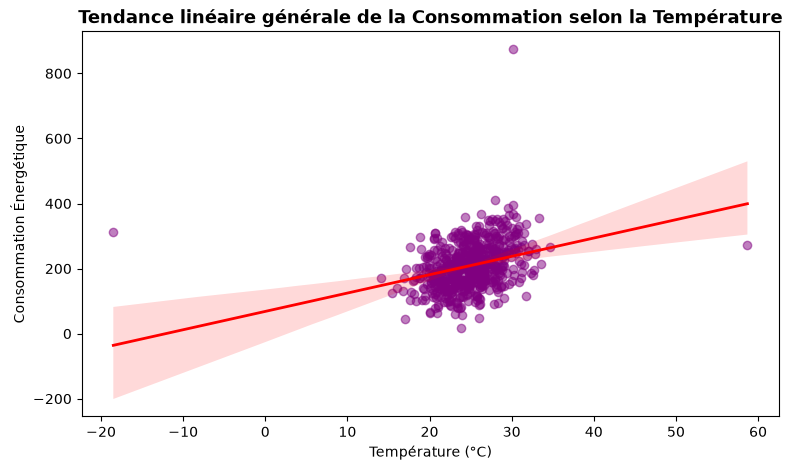

In [157]:
plt.figure(figsize=(9, 5))

# 'regplot' dessine le nuage et calcule la droite de tendance linéaire avec sa zone d'incertitude ombrée
sns.regplot(data=df, x='temperature', y='consommation', 
            scatter_kws={'alpha': 0.5, 'color': 'purple'}, 
            line_kws={'color': 'red', 'linewidth': 2})

plt.title("Tendance linéaire générale de la Consommation selon la Température", fontsize=13, fontweight='bold')
plt.xlabel("Température (°C)")
plt.ylabel("Consommation Énergétique")
plt.show()

## Partie 8 – Régression avec lmplot() 
Etudier graphiquement une tendance entre température et consommation par bâtiment 

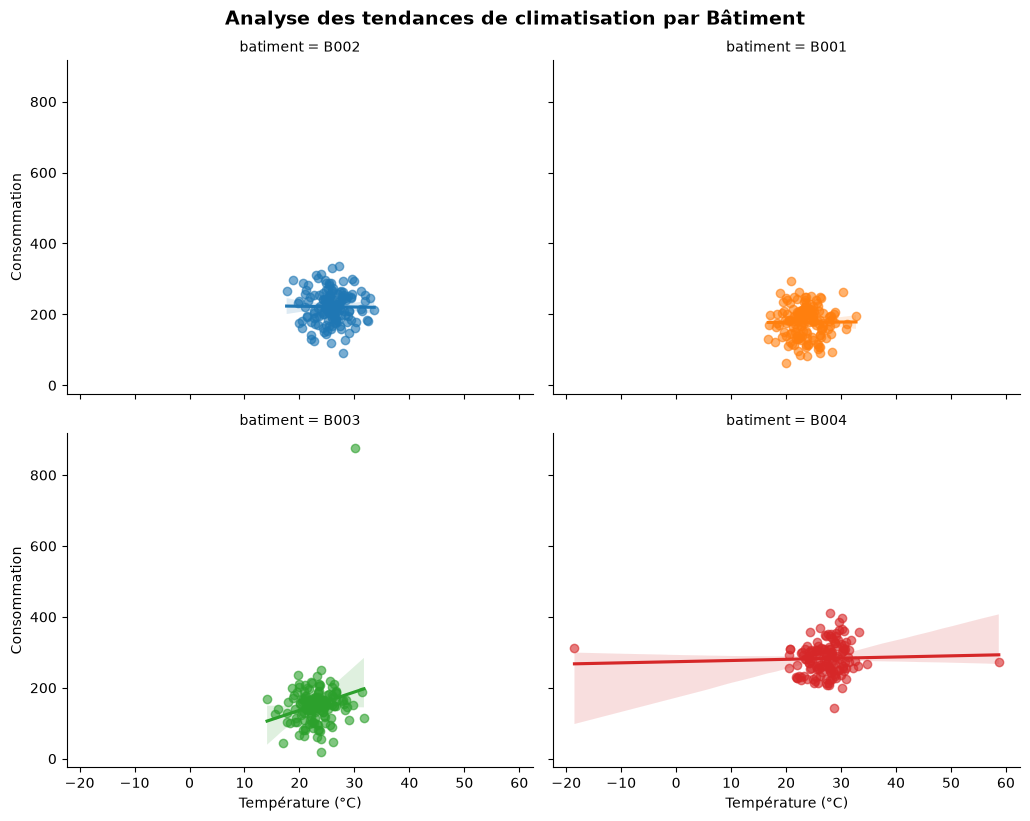

In [158]:
#'lmplot' permet de dessiner plusieurs régressions séparées sur une grille de figures autonomes
# 'col' découpe un graphique distinct par bâtiment, 'col_wrap=2' limite à 2 colonnes d'affichage
g = sns.lmplot(data=df, x='temperature', y='consommation', hue='batiment', col='batiment', 
               col_wrap=2, height=4, aspect=1.3, scatter_kws={'alpha': 0.6})

g.set_axis_labels("Température (°C)", "Consommation")
g.fig.suptitle("Analyse des tendances de climatisation par Bâtiment", y=1.02, fontsize=14, fontweight='bold')
plt.show()

## Partie 9 – Corrélations 
### 1) Utiliser Pandas pour calculer les corrélations entre température, humidité, pression et consommation.  

In [159]:
colonnes = ["temperature", "humidite", "pression", "consommation"]

correlations = df[colonnes].corr()


### 2) Afficher la matrice de corrélation obtenue avec Pandas 

In [160]:
print("Matrice de corrélation obtenue avec Pandas :")
correlations.round(2)

Matrice de corrélation obtenue avec Pandas :


,temperature,humidite,pression,consommation
temperature,1.00,-0.01,0.06,0.32
humidite,-0.01,1.00,0.05,-0.05
pression,0.06,0.05,1.00,0.06
consommation,0.32,-0.05,0.06,1.00


### 3) Afficher le heatmap de la corrélation pour identifier :

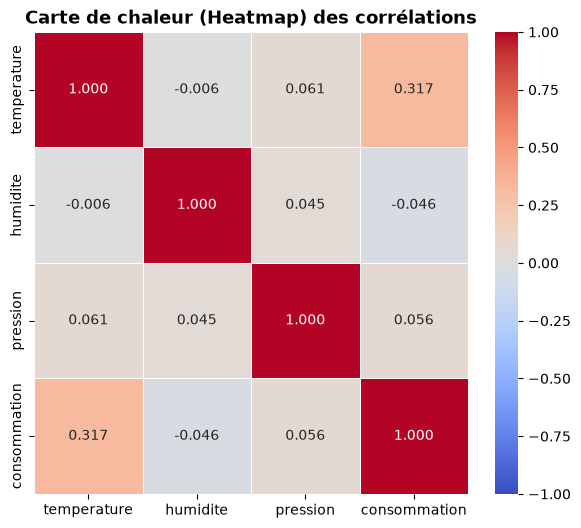

In [161]:
plt.figure(figsize=(7, 6))

# 'annot=True' affiche les coefficients dans les cases, 'fmt=".3f"' force trois décimales
# 'cmap="coolwarm"' applique un gradient de couleurs du bleu (négatif) au rouge (positif)
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, linewidths=0.5)

plt.title("Carte de chaleur (Heatmap) des corrélations", fontsize=13, fontweight='bold')
plt.show()


*   **a) Les corrélations positives :** La seule véritable liaison positive observée concerne la **Température et la Consommation (+0,317)**. Cette hausse simultanée valide scientifiquement le besoin en électricité induit par la climatisation lors des hausses thermiques.
*   **b) Les corrélations négatives :** Il n'existe **aucune corrélation négative notable** dans ce jeu de données (les coefficients sont quasi nuls).
*   **c) Les corrélations proches de zéro :** La **Pression atmosphérique** est statistiquement indépendante et décorrélée de toutes les autres variables (+0,061 avec la température, +0,045 avec l'humidité, +0,056 avec la consommation). De même, l'**Humidité** montre un coefficient nul par rapport à la température (-0,006) et la consommation (-0,046).
*   **d) Les variables fortement liées :** Aucun couple n'affiche de dépendance extrêmement forte (proche de 1 ou -1), mais la paire **Température et Consommation Énergétique** représente de loin l'association la plus marquante de l'étude.

## Partie 10 – Analyse multivariée avec pairplot() 
En considérant la température, l’humidité, la pression et la consommation, réaliser un graphique qui 
affiche simultanément les distributions individuelles et les scatter plots entre variables. 

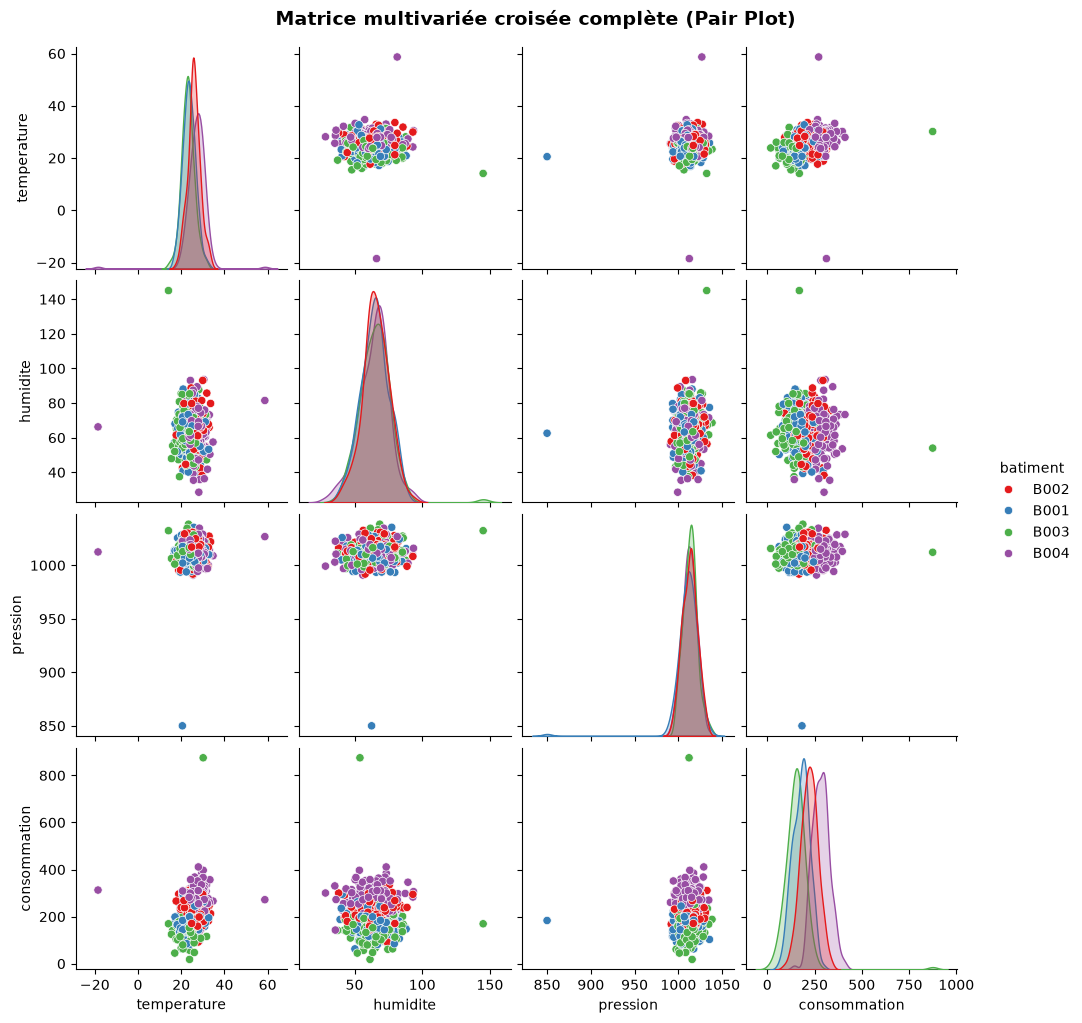

In [162]:
# 'pairplot' croise toutes les variables numériques de la liste et les colore selon le bâtiment (hue)
# Les histogrammes de distribution se placent sur la diagonale, et les nuages de points en dehors
g = sns.pairplot(data=df, vars=['temperature', 'humidite', 'pression', 'consommation'], hue='batiment', palette='Set1', height=2.5)

g.fig.suptitle("Matrice multivariée croisée complète (Pair Plot)", y=1.02, fontsize=14, fontweight='bold')
plt.show()

## Partie 11 : Sauvegarde des graphiques 
Sauvegarder les graphiques dans le sous-dossier exports

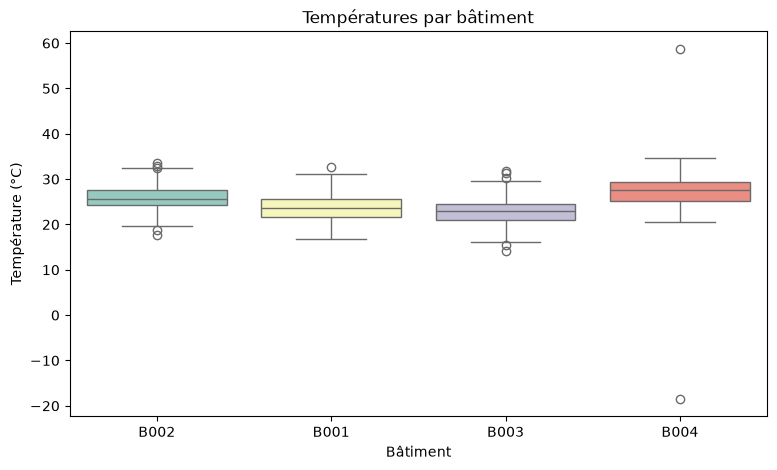

In [163]:
import os

os.makedirs("../exports", exist_ok=True)

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="batiment", y="temperature", hue="batiment", palette="Set3", legend=False)

plt.title("Températures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")

plt.savefig("../exports/temperature.png", dpi=150, bbox_inches="tight")
plt.savefig("../exports/temperature.pdf", bbox_inches="tight")

plt.show()
plt.close()